In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import re, torch
import torch.nn.functional as F
import gc
%matplotlib inline

device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

In [2]:
# import gc, torch
#
# # 1) Drop references to big GPU tensors/models you don't need
# for name in ["x_train","y_train","x_dev","y_dev","x_test","y_test","emb","h","logits","probs","loss"]:
#     if name in globals():
#         del globals()[name]
#
# # 2) Force cleanup
# gc.collect()
# torch.cuda.empty_cache()
# torch.cuda.ipc_collect()

In [3]:
# load data nad setup vocab
block_size = 4                 # number of previous words
BOS, EOS, UNK = "<BOS>", "<EOS>", "<UNK>"

def tok(s):
    return re.findall(r"\w+|[^\w\s]", s.lower())

# sentences: list[str] (real multi-word text, not names.txt)
sentences = open("sentences.txt").read().splitlines()
all_tokens = [w for s in sentences for w in tok(s)]
vocab = [BOS, EOS, UNK] + sorted(set(all_tokens))
stoi = {w:i for i,w in enumerate(vocab)}
itos = {i:w for w,i in stoi.items()}
vocab_size = len(stoi)      # word vocab, including special tokens like <BOS>/<EOS>/<UNK>
hidden_size = 200
emb_size = 256
BATCH_SIZE = 32


In [4]:
# build dataset
def build_dataset(sentences):
    X, Y = [], []
    for s in sentences:
        words = [BOS]*block_size + tok(s) + [EOS]
        for i in range(block_size, len(words)):
            ctx = words[i-block_size:i] # previous 4 words
            tgt = words[i] # target word
            # print(ctx, "--->",  tgt)
            X.append([stoi.get(w, stoi[UNK]) for w in ctx])
            Y.append(stoi.get(tgt, stoi[UNK]))
    return torch.tensor(X, dtype=torch.long, device=device), torch.tensor(Y, dtype=torch.long, device=device)
x_train, y_train = build_dataset(sentences[:int(0.8*len(sentences))])
x_dev, y_dev = build_dataset(sentences[int(0.8*len(sentences)):int(0.9*len(sentences))])
x_test, y_test = build_dataset(sentences[int(0.9*len(sentences)):])


In [5]:
g = torch.Generator(device=device).manual_seed(2147483647)
#F.one_hot(torch.tensor(5), num_classes=27).float() @ C
C = torch.randn((vocab_size, emb_size), requires_grad=True, generator=g, device=device)
W1 = torch.randn((emb_size * block_size, hidden_size), requires_grad=True, generator=g, device=device)
b1 = torch.randn(hidden_size, requires_grad=True, generator=g, device=device)
W2 = torch.randn((hidden_size, vocab_size), requires_grad=True, generator=g, device=device)
b2 = torch.randn(vocab_size, requires_grad=True, generator=g, device=device)
parameters = [C, W1, b1, W2, b2]
print('number of parameters:', sum(p.nelement() for p in parameters))

number of parameters: 5446333


In [6]:
lossi = []
stepi = []

Final Loss =  9.87903881072998


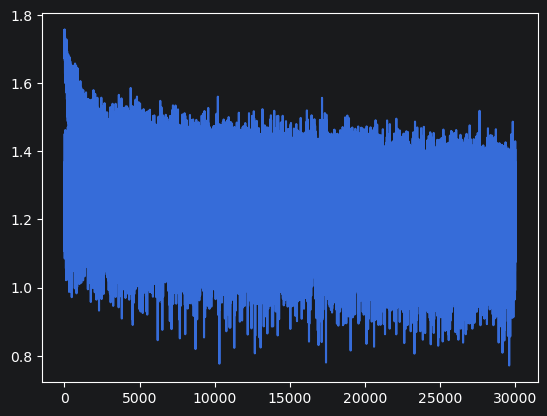

In [12]:
# training loop
for i in range(30000):
  # minibatch of 32
  ix = torch.randint(0, x_train.shape[0], (BATCH_SIZE,), generator=g, device=device)
  x_batch, y_batch = x_train[ix], y_train[ix]
  emb = C[x_batch]
  z = emb.view(-1, emb_size * block_size)
  h = torch.tanh(z @ W1 + b1)
  logits = h @ W2 + b2
  # probs = F.softmax(logits, dim=1)
  # loss = -torch.log(probs[torch.arange(BATCH_SIZE), Yb]).mean()
  loss = F.cross_entropy(logits, y_batch)   # y_batch shape (B,)
  # print(i, loss.item())
  # set grad to 0, zero_grad()
  for p in [C, W1, b1, W2, b2]:
    p.grad = None
  loss.backward()

  lr = 0.1 if i < 2000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

# softmax activation
# counts = logits.exp()
# prob = counts / counts.sum(1, keepdim=True)
# built-in softmax

print('Final Loss = ', loss.item())

# computes all gradients
for p in parameters:
  p.data -= 0.01 * p.grad

plt.plot(stepi, lossi)

In [13]:
emb = C[x_dev]
h = torch.tanh(emb.view(-1, emb_size * block_size) @ W1 + b1) # shape ()
logits = h @ W2 + b2
loss = F.cross_entropy(logits, y_dev)
loss

tensor(15.0686, device='cuda:1', grad_fn=<NllLossBackward0>)

In [14]:
emb = C[x_test]
h = torch.tanh(emb.view(-1, emb_size * block_size) @ W1 + b1) # shape ()
logits = h @ W2 + b2
loss = F.cross_entropy(logits, y_test)
loss

tensor(15.1947, device='cuda:1', grad_fn=<NllLossBackward0>)

In [15]:
# # visualize the chars
# C_plot = C.detach().cpu()
#
# plt.figure(figsize=(8, 8))
# plt.scatter(C_plot[:, 0].numpy(), C_plot[:, 1].numpy(), s=200)
# for i in range(C_plot.shape[0]):
#     plt.text(C_plot[i, 0].item(), C_plot[i, 1].item(), itos[i],
#              ha="center", va="center", color="white")
# plt.grid(True, which="both")


In [16]:
# ---- inference: next-word prediction for a 4-word context ----
@torch.no_grad()
def predict_next_word(context_text):
    words = tok(context_text)
    ctx = ([BOS] * block_size + words)[-block_size:]
    x = torch.tensor([[stoi.get(w, stoi[UNK]) for w in ctx]], dtype=torch.long, device=device)

    emb = C[x]
    h = torch.tanh(emb.view(1, -1) @ W1 + b1)
    logits = h @ W2 + b2
    probs = F.softmax(logits, dim=1)[0]

    probs[stoi[BOS]] = 0.0
    probs[stoi[EOS]] = 0.0
    probs = probs / probs.sum()

    ix = torch.argmax(probs).item()
    return itos[ix]

word = predict_next_word("My business is doing well and I am very happy with the ")
print("predicted next word:", word)

predicted next word: moths


In [19]:
#---- optional: generate a word ----
@torch.no_grad()
def generate_sentence(max_tokens=30):
    context = [stoi[BOS]] * block_size
    out = []

    for _ in range(max_tokens):
        x = torch.tensor([context], dtype=torch.long, device=device)
        emb = C[x]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)[0]

        # don't resample BOS
        probs[stoi[BOS]] = 0.0
        probs[stoi[EOS]] = 0.0
        probs = probs / probs.sum()

        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]

        if ix == stoi[EOS]:
            break

        out.append(itos[ix])

    return " ".join(out)

sample = generate_sentence()
sample

'much in ? into off soldier ! lips chamberlain stumbling beloved mettest badest greed principal sneak premises daring quean your grace king water defective childhood mature plashy warn cheveril chancellor'